In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import benchmarks
import itertools
import h5py
import glob
import os
importlib.reload(benchmarks)

<module 'benchmarks' from '/home/rtat/Spin-tracking/benchmarks/benchmarks.py'>

In [2]:
physics = {'B0' : '5e-6, 0, 0',
           'L' : '1.0, 1.0, 1.0',
           'yi' : '0.0, 0.0, 1.0',
           'm' : '1.20239e-26',
           't0' : '0.0',
           'tf' : '10.0',
           'T' : '0.25',
           'gamma' : '-2.038e8',
           'a' : '0.0',
           'w' : '6.28318530718e3',
           'diffuse' : '0.0',
           'gas_coll' : 'true',
           'gravity' : 'false',
           'dist' : 'M'}

integration = {'numParticles' : '512',
               'numPerGPUBlock' : '256',
               'ioutInt' : '20.0',
               'integratorType' : '6',
               'seed' : 'rand',
               'h': '1e-4'}

scratch_dir = '/home/rtat/scratch/high_temp_test'

In [17]:
for _ in range(5):
    integration['integratorType'] = '0'
    integration['ioutInt'] = '2.0'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        E_range = np.linspace(0, 1e7, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'E2_benchmark'))
    pb.run()
    
    integration['integratorType'] = '6'
    integration['ioutInt'] = '0.1'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        E_range = np.linspace(0, 1e7, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'E2_benchmark'))
    pb.run()
    
    integration['integratorType'] = '7'
    integration['ioutInt'] = '0.1'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        E_range = np.linspace(0, 1e7, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'E2_benchmark'))
    pb.run()

    integration['integratorType'] = '0'
    integration['ioutInt'] = '2.0'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        Gzz_range = np.linspace(0, 3e-9, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'B2_benchmark'))
    pb.run()
    
    integration['integratorType'] = '6'
    integration['ioutInt'] = '0.1'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        Gzz_range = np.linspace(0, 3e-9, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'B2_benchmark'))
    pb.run()
    
    integration['integratorType'] = '7'
    integration['ioutInt'] = '0.1'
    pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                        Gzz_range = np.linspace(0, 3e-9, num=5),
                                        executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'B2_benchmark'))
    pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic
iter 0, duration 2, 3057
iter 1, duration 4, 2965
iter 2, duration 6, 2968
iter 3, duration 8, 2939
iter 4, duration 10, 2974
{0, 0.970324, 0.241807}
16527
iter 0, duration 2, 2979
iter 1, duration 4, 2873
iter 2, duration 6, 2909
iter 3, duration 8, 2882
iter 4, duration 10, 2946
{0.000155264, 0.970288, 0.241889}
14984
iter 0, duration 2, 3061
iter 1, duration 4, 2909
iter 2, duration 6, 2908
iter 3, duration 8, 2955
iter 4, duration 10, 2952
{0.00038776, 0.970179, 0.24214}
15187
iter 0, duration 2, 2995
iter 1, duration 4, 2958
iter 2, duration 6, 2926
iter 3, duration 8, 2929
iter 4, duration 10, 2948
{0.000424388, 0.970017, 0.242551}
15141
iter 0, duration 2, 3040
iter 1, duration 4, 2961
iter 2, duration 6, 2930
iter 3, duration 8, 2947
iter 4, duration 10, 2957
{0.000444043, 0.969748, 0.243118}
15220
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic
iter 0, duration 0.1, 513
iter

In [3]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'E2_benchmark'))
data = pb.analyze(files=glob.glob(os.path.join('/home/rtat/scratch/E2_benchmark', 'out_*.hdf5')))
Evalues = set(data['E'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = (data['E'] == ev) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('E')
tf = compiled_data['tf'].iloc[0]

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic


Text(0, 0.5, 'Shift [rad/s]')

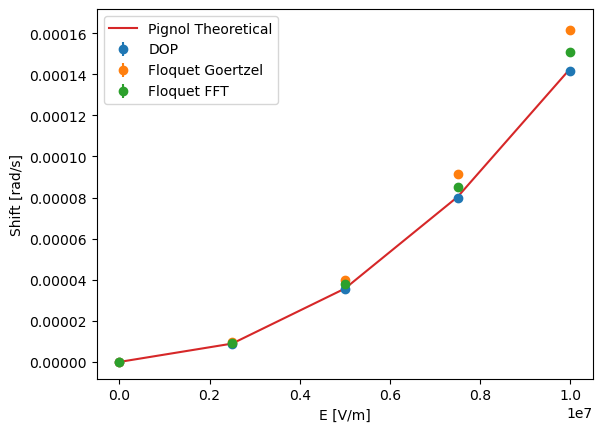

In [4]:
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['E'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

plt.plot(compiled_data[compiled_data['iType'] == 0]['E'], -compiled_data[compiled_data['iType'] == 0]['expected_shift'],
        label='Pignol Theoretical')
plt.legend()
plt.xlabel('E [V/m]')
plt.ylabel('Shift [rad/s]')

In [5]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join('/home/rtat/scratch', 'B2_benchmark'))
data = pb.analyze(files=glob.glob(os.path.join('/home/rtat/scratch/B2_benchmark', 'out_*.hdf5')))
Gvalues = set(data['Gzz'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, gzz in itertools.product(iTypes, Gvalues):
    mask = (data['Gzz'] == gzz) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('Gzz', gzz)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('Gzz')
tf = compiled_data['tf'].iloc[0]

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
Regime: diffusive adiabatic


Text(0, 0.5, 'Shift [rad/s]')

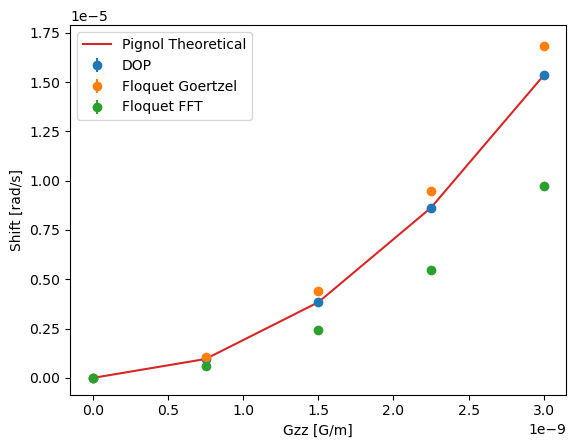

In [6]:
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['Gzz'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

plt.plot(compiled_data[compiled_data['iType'] == 0]['Gzz'], -compiled_data[compiled_data['iType'] == 0]['expected_shift'],
        label='Pignol Theoretical')
plt.legend()
plt.xlabel('Gzz [G/m]')
plt.ylabel('Shift [rad/s]')